# Case Study: Bayesian logistic regression with a Laplace prior via SOUL with Metropolis-Hastings with Standardised Scaling step.

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))  
sys.path.append(project_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from algorithms import sig, log_p_laplace, soul_mh_ss_decay, soul_mh_ss, proximal_map_laplace_iterative, proximal_map_laplace_approx, mypipla, mypgd
#pip_ula, prox_pgd, proximal_map_laplace_iteration_total, pipgla, proximal_map_laplace_approx_total
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

os.chdir(project_root)

# Obtain synthetic dataset for Laplace prior case

In [2]:
from scipy.stats import laplace, bernoulli
# Data and design matrix
np.random.seed(3)
design_matrix = np.random.uniform(low = -1.0, high = 1.0, size = (900, 50))
x_unknown = laplace.rvs(loc = -4, size = (50, 1))
parameter_bernoulli = sig(np.matmul(design_matrix, x_unknown))
data_experiment = bernoulli.rvs(np.array(parameter_bernoulli[:, 0]), size = 900)
labels = np.expand_dims(data_experiment, axis=1)
theta_true = -4

## SOUL Metropolis-Hastings with Standardised Scaling

In [4]:
# single run test

# --- SOUL MHSS Setup ---
D = 50
T = 800  # Outer optimization steps
M = 30  # MH steps per outer loop
B = 5  # Burn-in steps
delta_step = 0.08
proposal_std = 0.008 # 0.08 for soul_mh
b_scale = 1.0 # Scale parameter for the Laplace prior

# Define reasonable bounds for latent variables X
lower_bounds = np.full((D, 1), -10.0)
upper_bounds = np.full((D, 1), 5.0)

# Initializations
th0 = np.array([[-9.0]])
x0_M = np.zeros((D, 1))

# Run the adapted SOUL-MHSS algorithm
th_list, x_samples = soul_mh_ss_decay(
    log_p=log_p_laplace,
    th0=th0,
    x0_M=x0_M,
    y_l=design_matrix,
    y_f=labels,
    T=T,
    M=M,
    B=B,
    delta_step=delta_step,
    proposal_std=proposal_std,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    b=b_scale,
    gamma = 0.9995
)

print("Final estimated theta:", th_list[-1][0, 0])
print("True theta (loc parameter): -4.0")

t= 13 current_delta= 0.07948155714357184 and theta is  [[-7.96363273]] mean(x_t)= -0.8289694366873545 accept rate= 0.16666666666666666
t= 26 current_delta= 0.07896647407458594 and theta is  [[-6.93398168]] mean(x_t)= -1.672326326586861 accept rate= 0.18333333333333332
t= 39 current_delta= 0.07845472901981984 and theta is  [[-5.91100331]] mean(x_t)= -2.6372186325229645 accept rate= 0.18803418803418803
t= 52 current_delta= 0.07794630034715319 and theta is  [[-4.91898749]] mean(x_t)= -3.303820879234148 accept rate= 0.2
t= 65 current_delta= 0.07744116656465337 and theta is  [[-4.20511864]] mean(x_t)= -3.787790033508601 accept rate= 0.20974358974358975
t= 78 current_delta= 0.07693930631966703 and theta is  [[-4.09535049]] mean(x_t)= -4.119314756915907 accept rate= 0.21794871794871795
t= 91 current_delta= 0.07644069839791741 and theta is  [[-4.07239642]] mean(x_t)= -4.0648668267655115 accept rate= 0.22087912087912087
t= 104 current_delta= 0.07594532172260766 and theta is  [[-4.06414745]] mea

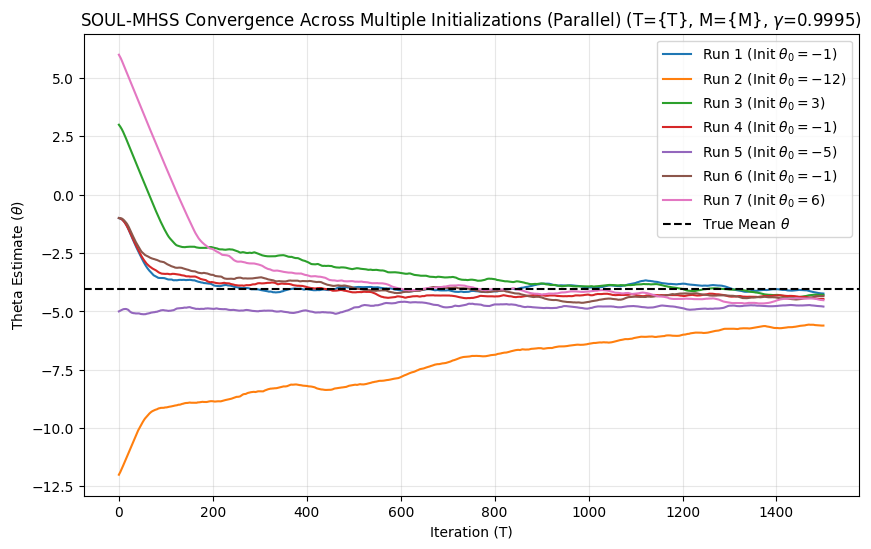

In [5]:
from joblib import Parallel, delayed

# --- Experiment Parameters ---
T = 1500  # Outer steps
B = 5
M = 35

# Hyper-parameters for SOUL-MHSS
delta_step = 0.05
proposal_std = 0.008 # 0.08 for soul_mh
b_scale = 1

# Define bounds for the standardized scaling
D = design_matrix.shape[1]
lower_bounds = np.full((D, 1), -15.0)
upper_bounds = np.full((D, 1), 10.0)


def run_single_soul_mh_ss_decay(run_idx):
    theta0_val = np.random.randint(-15, 10)
    th0 = np.array([[float(theta0_val)]])

    # Draw X0 within bounds
    X0_M = np.random.uniform(
        low=lower_bounds[0, 0], high=upper_bounds[0, 0], size=(D, M)
    )

    th_list, x_values = soul_mh_ss_decay(
        log_p=log_p_laplace,
        th0=th0,
        x0_M=X0_M,
        y_l=design_matrix,
        y_f=labels,
        T=T,
        M=M,
        B=B,
        delta_step=delta_step,
        proposal_std=proposal_std,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        b= b_scale,
        gamma=0.9995
    )

    th_trajectory = np.array([t[0, 0] for t in th_list])
    return run_idx, theta0_val, th_trajectory, x_values


# Run parallel executions
results = Parallel(n_jobs=-2)(
    delayed(run_single_soul_mh_ss_decay)(i) for i in range(7)
)

# Plotting convergence
fig = plt.figure(figsize=(10, 6))

theta_soul_ss = []
X_soul_ss = []

for run_idx, theta0_val, th_trajectory, x_values in results:
    theta_soul_ss.append(th_trajectory)
    X_soul_ss.append(x_values)

    plt.plot(
        th_trajectory,
        label=f"Run {run_idx + 1} (Init $\\theta_0={theta0_val}$)",
    )

plt.axhline(
    y=np.mean(x_unknown),
    color="black",
    linestyle="dashed",
    label="True Mean $\\theta$",
)

plt.title("SOUL-MHSS Convergence Across Multiple Initializations (Parallel) (T={T}, M={M}, $\\gamma$=0.9995)")
plt.xlabel("Iteration (T)")
plt.ylabel("Theta Estimate ($\\theta$)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.show()
fig.savefig("soul_mh_ss_convergence_parallel.pdf", format="pdf")

Relative error:

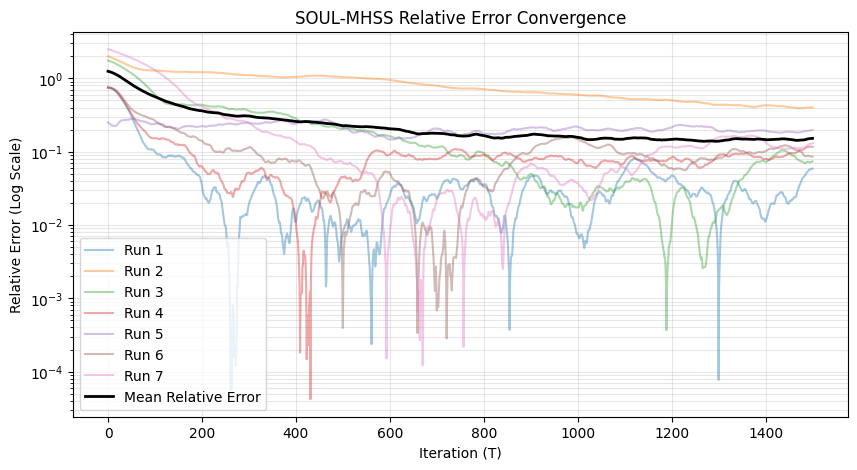

In [6]:
# Convert list of trajectories into a 2D numpy array of shape (num_runs, T + 1)
theta_soul_ss_arr = np.array(theta_soul_ss)

# Compute relative error trajectory for each run
relative_error_trajectories_ss = np.abs(theta_soul_ss_arr - theta_true) / np.abs(
    theta_true
)

# Mean relative error across all runs per iteration step
mean_relative_error_per_step_ss = np.mean(relative_error_trajectories_ss, axis=0)

# Plot Relative Error over iterations
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for idx, err_traj in enumerate(relative_error_trajectories_ss):
    plt.plot(err_traj, alpha=0.4, label=f"Run {idx + 1}")

plt.plot(
    mean_relative_error_per_step_ss,
    color="black",
    linewidth=2,
    label="Mean Relative Error",
)
plt.yscale("log")  # Log scale highlights convergence speed clearly
plt.title("SOUL-MHSS Relative Error Convergence")
plt.xlabel("Iteration (T)")
plt.ylabel("Relative Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()